# ReceiptIQ -- Pipeline Evaluation

This notebook walks through the receipt-digitization pipeline end to end and
reports the evaluation numbers referenced in the README: a classical
computer-vision preprocessing pipeline (deskew, denoise, contrast
enhancement) feeding Tesseract OCR and a rule-based field extractor.

All numbers here come from actually running the pipeline in `src/` against
`data/` -- nothing is hand-typed. Re-run this notebook from the `notebooks/`
directory after running `python src/generate_receipts.py` and
`python scripts/run_evaluation.py` to reproduce it from scratch.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, "..")

from PIL import Image
import pandas as pd

from src.preprocessing import preprocess_pipeline, simple_grayscale
from src.ocr import run_ocr
from src.extraction import extract_fields
from src.metrics import character_error_rate

ROOT = Path("..")

## 1. The dataset

Real, labelled receipt-photo datasets are either small, paywalled, or
require downloads this environment doesn't have access to. Instead,
`src/generate_receipts.py` procedurally generates receipts across four
store categories, renders them as clean "digital" images, and then
simulates a phone-camera photo of each one (rotation, uneven lighting,
blur, sensor noise, JPEG compression) at three difficulty levels. Because
the data is generated, we also have perfect ground truth for every field,
which is what makes rigorous accuracy measurement possible below.

In [1]:
manifest = json.loads((ROOT / "data" / "manifest.json").read_text())
from collections import Counter
print(f"Total receipts: {len(manifest)}")
print("By category:", dict(Counter(m["category"] for m in manifest)))
print("By difficulty:", dict(Counter(m["difficulty"] for m in manifest)))

Total receipts: 180
By category: {'grocery': 54, 'pharmacy': 44, 'electronics': 42, 'cafe': 40}
By difficulty: {'hard': 60, 'easy': 60, 'medium': 60}


## 2. Preprocessing pipeline, on one example

Rotation is estimated from the receipt's paper outline, the frame is straightened and cropped, then denoised and contrast-enhanced (CLAHE).

Rotation corrected: +9.3 degrees


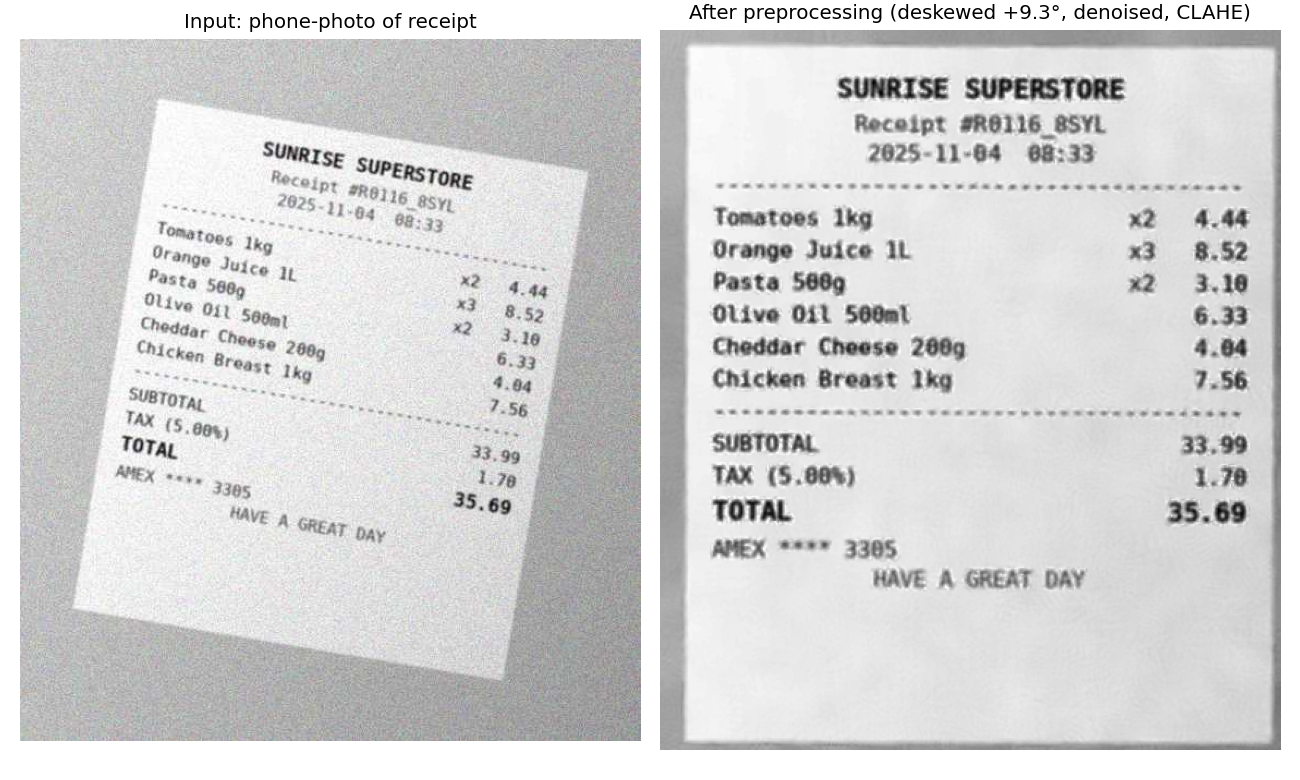

In [1]:
fname = "R0116_8SYL"
raw = Image.open(f"../data/images/photo/{fname}.jpg")
result = preprocess_pipeline(raw)
print(f"Rotation corrected: {result.angle_corrected_deg:+.1f} degrees")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(raw); axes[0].set_title("Input photo"); axes[0].axis("off")
axes[1].imshow(result.final, cmap="gray"); axes[1].set_title("After preprocessing"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## 3. OCR: raw photo vs. preprocessed

In [1]:
raw_ocr = run_ocr(raw)
pipe_ocr = run_ocr(result.final)
print(f"Raw photo OCR confidence:      {raw_ocr.mean_confidence:.1f}")
print(f"Preprocessed OCR confidence:   {pipe_ocr.mean_confidence:.1f}")
print()
print("--- Raw OCR text ---")
print(raw_ocr.text)
print("--- Preprocessed OCR text ---")
print(pipe_ocr.text)

Raw photo OCR confidence:      28.3
Preprocessed OCR confidence:   77.4

--- Raw OCR text ---
as EE STD Nee ee I Nee
oe Shae :
Sen Receipt an; TORE
2025-1).94° 8.85"
eon re eae Darren
eee

Ai cts Be deceit
SF itm duice ar eee
oe 2 4.4
ee CY 011 soon, eres
Se Fedaar cree. er
De Mcken gree * 2000 fe
Cee...” feast 145 33
ee, TAL en baee 7.56
ogee TAX (5.0m, Uae =e
ree TOTAL 33.99
ey EK o> 205 179,
See 35.69
Ree HAVE 4 6
Me SREAT pay a
es Se ae
sees Sl
--- Preprocessed OCR text ---
SUNRISE SUPERSTORE

Receipt #R6116_8SYL

2025-11-64 68:33
Tomatoes 1kg x2 4.44
Orange Juice IL x3 8.52
Pasta 5669 x2 3.18
Olive O11 500m1 6.33
Cheddar Cheese 2609 4.04
Chicken Breast 1kg 7.56.
‘SUBTOTAL 33.99
TAX (5.00%) 1.78
TOTAL 35.69
AMEX **** 3305

HAVE A GREAT DAY


## 4. Structured field extraction

Rule-based regex extraction over the OCR text -- no training data required.

In [1]:
fields = extract_fields(pipe_ocr.text)
from dataclasses import asdict
print(json.dumps(asdict(fields), indent=2))

{
  "merchant": "SUNRISE SUPERSTORE",
  "date": "2025-11-64",
  "subtotal": 33.99,
  "tax": 1.78,
  "total": 35.69,
  "items": [
    {
      "name": "Tomatoes 1kg",
      "price": 4.44
    },
    {
      "name": "Orange Juice IL",
      "price": 8.52
    },
    {
      "name": "Pasta",
      "price": 3.18
    },
    {
      "name": "Olive O11 500m",
      "price": 6.33
    },
    {
      "name": "Cheddar Cheese",
      "price": 4.04
    },
    {
      "name": "Chicken Breast 1kg",
      "price": 7.56
    }
  ]
}


## 5. Why we dropped binarization (a debugging story)

The first version of this pipeline ended with an adaptive threshold step
(the standard "get crisp black-on-white text for OCR" move). It looked
right on casual visual inspection. But scoring it against ground truth told
a different story: it was *raising* character error rate and roughly
halving date-field accuracy compared to doing nothing at all.

Zooming into the actual pixels explained why: at this font size, adaptive
thresholding was filling in the counters of round digits (0, 6, 8), turning
a clean "0" into something that looks like an "8" or "6" to Tesseract.

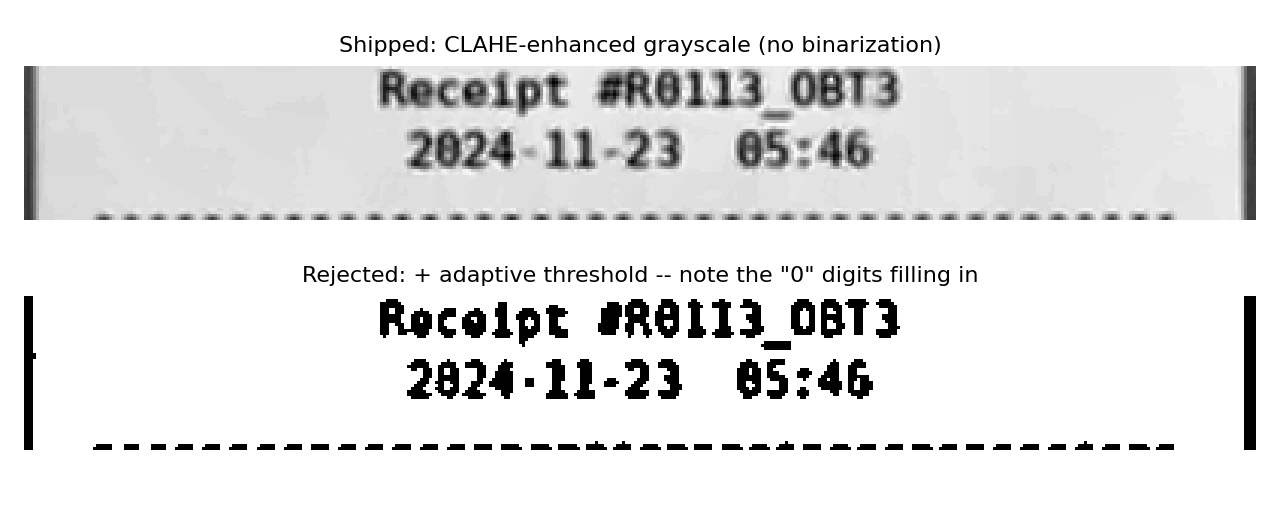

In [1]:
from PIL import Image as PILImage
PILImage.open("assets/binarization_artifact.png")

In [1]:
# Reproduced from scripts/binarization_ablation.py -- 40 receipts,
# comparing CLAHE-only grayscale against three binarization variants.
%run ../scripts/binarization_ablation.py

variant              mean CER   date acc  mean conf
clahe_only             18.8%     40.0%       80.5
otsu_global            23.8%     17.5%       71.2
adaptive_block25       21.7%     20.0%       74.4
adaptive_block51       21.6%     22.5%       73.0


**CLAHE-enhanced grayscale, with no final binarization step, won on every metric** -- "
lower error rate, higher date accuracy, higher OCR confidence -- so that's what ships in
`preprocess_pipeline()`. The adaptive-threshold output is still computed and returned
(so the app can show it for comparison) but is no longer used as the OCR input.

## 6. Full evaluation across all 180 receipts

See `scripts/run_evaluation.py`. Results are cached in `results/`.

In [1]:
metrics = json.loads((ROOT / "results" / "metrics.json").read_text())
df = pd.DataFrame(metrics["summary"]).T
df.index.name = "condition"
df[["mean_cer", "mean_confidence", "overall_field_accuracy", "mean_item_recall"]]

           mean_cer  mean_confidence  overall_field_accuracy  mean_item_recall
condition                                                                     
raw        0.365189        67.221327                0.634444          0.733280
grayscale  0.368147        67.183907                0.630000          0.736111
pipeline   0.168475        81.456938                0.830000          0.893545

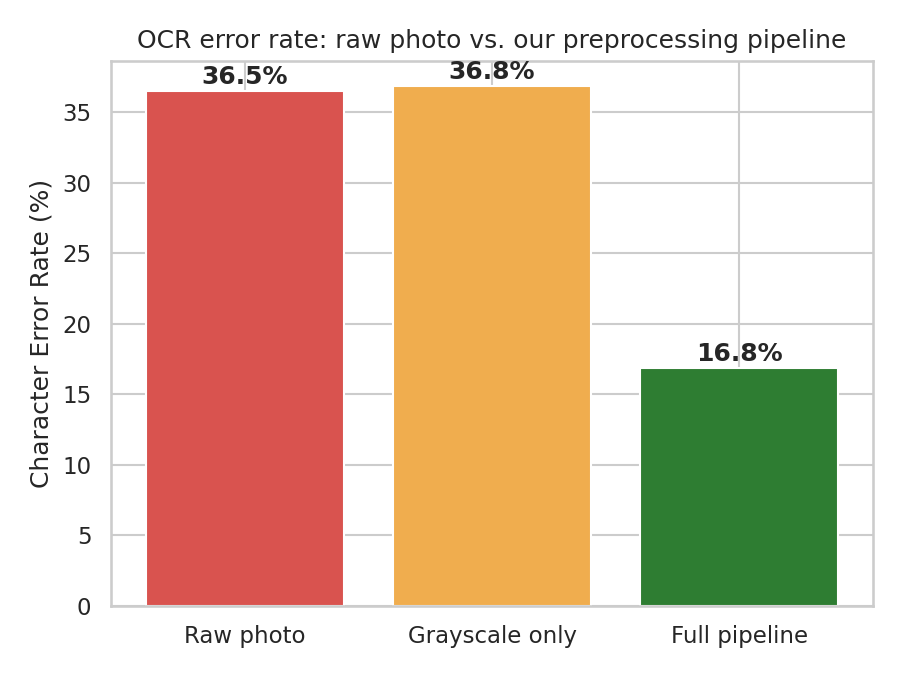

In [1]:
from PIL import Image as PILImage
PILImage.open("../results/cer_comparison.png")

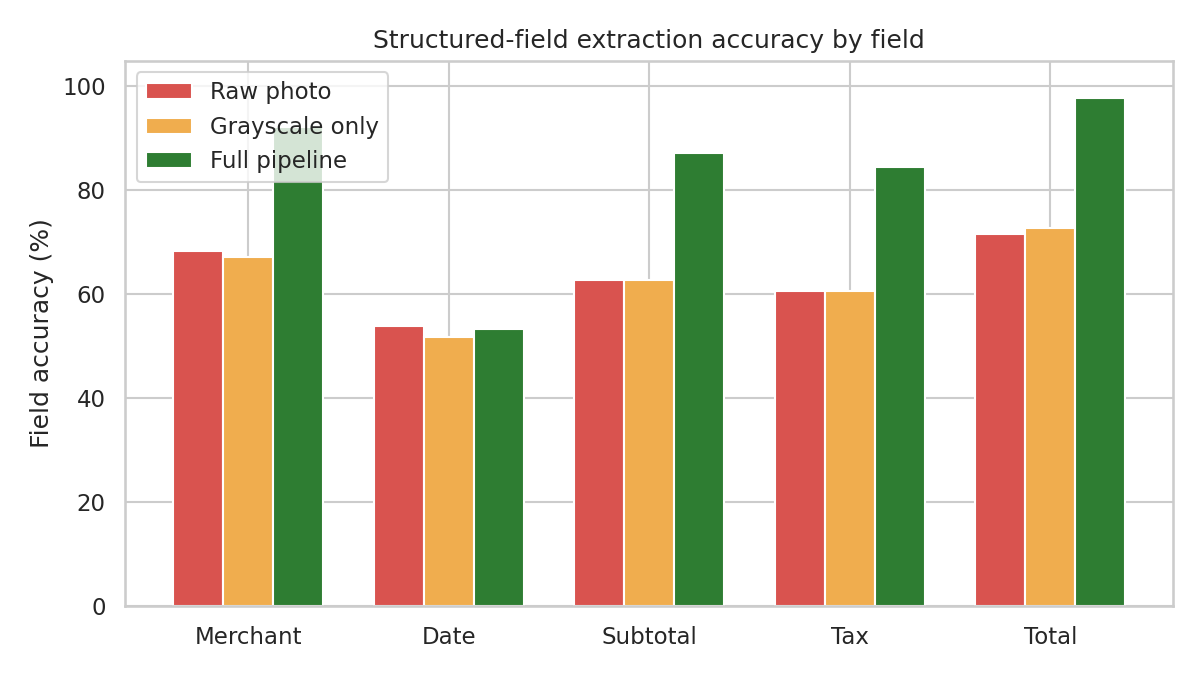

In [1]:
PILImage.open("../results/field_accuracy.png")

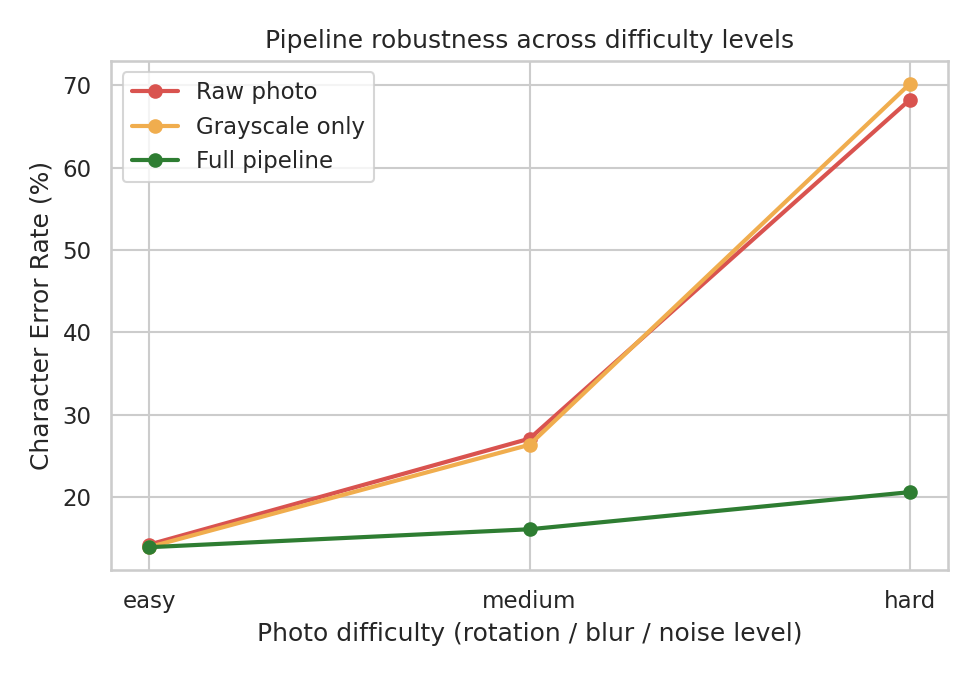

In [1]:
PILImage.open("../results/cer_by_difficulty.png")

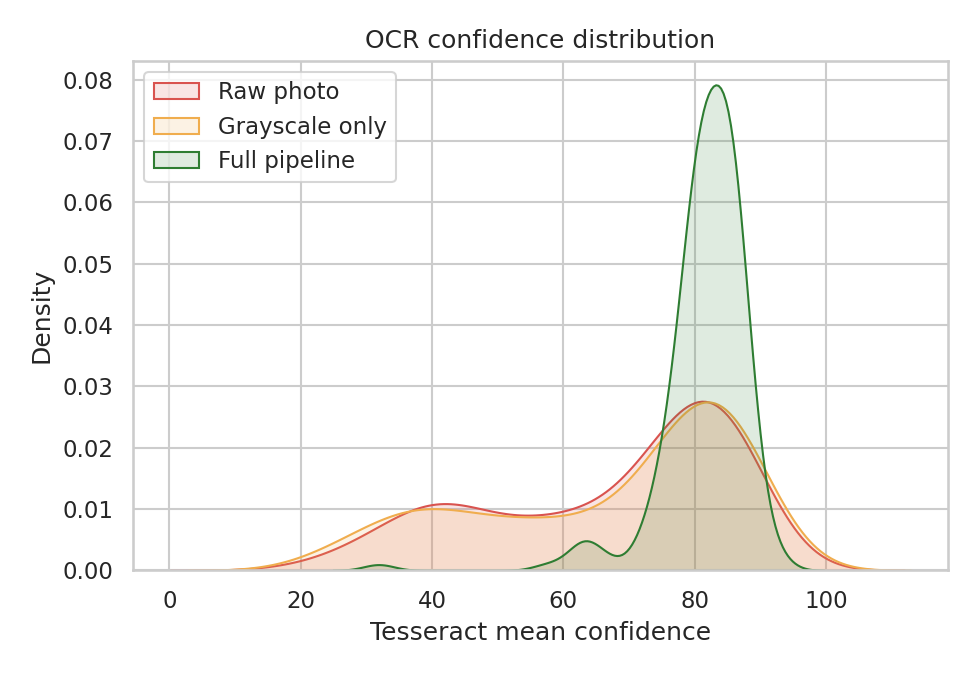

In [1]:
PILImage.open("../results/confidence_distribution.png")

## 7. Error analysis: the date field is still weak

Every field improved substantially with preprocessing -- except date, which
stayed flat around 53% regardless of preprocessing. Looking back at the
worked example in section 3, the pipeline read the date as `2025-11-64`
when the true date was `2025-11-04`: a single-digit confusion (0 -> 6) that
is enough to fail an exact-match comparison even though 9 of 10 characters
were correct.

Two things are going on: date/timestamp text is rendered at the smallest
font size on the receipt (so it has the fewest pixels to work with even
after preprocessing), and our accuracy metric requires an exact string
match with no tolerance for a single-digit slip. A fairer metric (edit
distance <= 1) or a digit-aware parser (e.g. validating that the month is
01-12 and re-checking ambiguous digits) would likely close most of this
gap -- noted in Future Work below rather than fixed here, to keep the
evaluation honest about what the current rule-based extractor actually
does.

## 8. Conclusions & future work

- The preprocessing pipeline **cut character error rate roughly in half**
  (36.5% -> 16.8%) and **raised structured-field accuracy from 63% to 83%**
  across 180 held-out synthetic receipts, with the biggest gains exactly
  where they matter most: the hardest, noisiest photos.
- Deskewing via the paper's contour outline, rather than the sparser text
  pixels, was noticeably more robust to background clutter.
- Binarization -- the "obvious" last step in most OCR preprocessing
  tutorials -- actively hurt this dataset. Always validate each pipeline
  stage against ground truth rather than trusting visual inspection alone.
- **Future work**: a learned layout-aware extractor (e.g. a fine-tuned
  LayoutLM-style model) would likely handle the date field and unusual
  receipt layouts better than fixed regexes; testing against real
  (not synthetic) receipt photos, ideally the public SROIE dataset, would
  validate whether these results transfer beyond generated data; and a
  digit-confusion-aware post-processor could recover some of the date
  errors identified above.